# Эксперименты: Quality + Tokens Prediction
## Сравнение моделей для LLM Router

В данном ноутбуке строится качество ответа R², токены R² — отдельный регрессор на каждую LLM в пуле.

Сравнение моделей: Ridge, CatBoost, k-NN.

Train/test: случайное разбиение 80/20.

Признаки: ручные фичи + PCA эмбеддинга (8…256 компонент) или полный эмбеддинг из данных + StandardScaler (ключ `scaled_emb_*_plus_feat`, размерность как в JSON).

Роутер ниже по ноутбуку по умолчанию обучает только CatBoost на выбранном `FEAT_KEY` (можно сменить модель вручную при необходимости).


In [128]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor

from catboost import CatBoostRegressor

In [129]:
QUALITY_FILE = "data/sprout_with_scores_judge.json"
MODELS = ["llama1b", "llama3b", "qwen7b"]

with open(QUALITY_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)
print(f"Загружено строк из {QUALITY_FILE}: {len(data)}")

merged_data = [
    item for item in data
    if all(m in item.get("models", {}) and "error" not in item["models"][m]
           for m in MODELS)
]

print(f"Записей после фильтра MODELS: {len(merged_data)}")

Загружено строк из data/sprout_with_scores_judge.json: 2154
Записей после фильтра MODELS: 2154


In [130]:
import sys
from pathlib import Path

COURSE_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(COURSE_ROOT / "carrot-like"))

from prompt_features import prompt_features

embeddings = np.array([item["embedding"] for item in merged_data])
prompt_feats = np.array(
    [prompt_features(item["prompt"]) for item in merged_data]
)

y_quality = np.zeros((len(merged_data), len(MODELS)))
y_tokens = np.zeros((len(merged_data), len(MODELS)))

for i, item in enumerate(merged_data):
    for j, m in enumerate(MODELS):
        y_quality[i, j] = item["models"][m].get("quality_score", 0.0)
        y_tokens[i, j] = item["models"][m].get("output_tokens", 256)

print(embeddings.shape, prompt_feats.shape, y_quality.shape, y_tokens.shape)

(2154, 768) (2154, 27) (2154, 3) (2154, 3)


### Среднее и дисперсия judge $Q$ по моделям генерации

По тем же `merged_data` и матрице `y_quality`, что ниже для регрессии: одна строка на промпт, три столбца — оценки судьи для ответов Llama-1B, Llama-3B, Qwen-7B. Значения переносятся в таблицу «Оценка качества моделей предсказания» в `project-final-report/main.typ`: среднее и выборочная дисперсия $s^2$ (деление на $n-1$).


In [146]:
_JUDGE_MODEL_LABELS = {
    "llama1b": "Llama-3.2-1B",
    "llama3b": "Llama-3.2-3B",
    "qwen7b": "Qwen-2.5-7B",
}
rows = []
for j, m in enumerate(MODELS):
    col = y_quality[:, j]
    n = int(col.shape[0])
    mu = float(np.mean(col))
    s2 = float(np.var(col, ddof=1)) if n > 1 else float("nan")
    rows.append(
        {
            "model_key": m,
            "model": _JUDGE_MODEL_LABELS[m],
            "n": n,
            "mean_Q": mu,
            "var_Q_sample": s2,
        }
    )
df_judge_stats = pd.DataFrame(rows)
display(df_judge_stats[["model", "n", "mean_Q", "var_Q_sample"]])
for r in rows:
    print(
        f"{r['model']}: mean={r['mean_Q']:.4f}, s²={r['var_Q_sample']:.5f} (n={r['n']})"
    )


,model,n,mean_Q,var_Q_sample
0,Llama-3.2-1B,2154,0.529851,0.197302
1,Llama-3.2-3B,2154,0.685608,0.177433
2,Qwen-2.5-7B,2154,0.787651,0.141408


Llama-3.2-1B: mean=0.5299, s²=0.19730 (n=2154)
Llama-3.2-3B: mean=0.6856, s²=0.17743 (n=2154)
Qwen-2.5-7B: mean=0.7877, s²=0.14141 (n=2154)


In [147]:
_row_idx = np.arange(len(embeddings), dtype=np.int64)

TEST_SIZE, SPLIT_RANDOM_STATE = 0.2, 179
X_train_emb, X_test_emb, X_train_feat, X_test_feat, y_train_q, y_test_q, y_train_t, y_test_t, idx_tr, idx_te = train_test_split(
    embeddings, prompt_feats, y_quality, y_tokens, _row_idx,
    test_size=TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)
print(
    "Random split (no stratify), n_train=",
    len(idx_tr),
    "n_test=",
    len(idx_te),
)

scaler_feat = StandardScaler()
X_train_feat_scaled = scaler_feat.fit_transform(X_train_feat)
X_test_feat_scaled = scaler_feat.transform(X_test_feat)

feature_variants = {}
for n_comp in (16, 32, 64):
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_emb)
    X_test_pca = pca.transform(X_test_emb)
    feature_variants[f"pca_{n_comp}_plus_feat"] = (
        np.hstack([X_train_pca, X_train_feat_scaled]),
        np.hstack([X_test_pca, X_test_feat_scaled]),
    )

scaler_emb = StandardScaler()
X_train_emb_scaled = scaler_emb.fit_transform(X_train_emb)
X_test_emb_scaled = scaler_emb.transform(X_test_emb)
_emb_dim = int(X_train_emb.shape[1])
feature_variants[f"scaled_emb_{_emb_dim}_plus_feat"] = (
    np.hstack([X_train_emb_scaled, X_train_feat_scaled]),
    np.hstack([X_test_emb_scaled, X_test_feat_scaled]),
)

ROUTER_FEAT_KEYS = tuple(feature_variants.keys())
len(feature_variants), ROUTER_FEAT_KEYS


Random split (no stratify), n_train= 1723 n_test= 431


(4,
 ('pca_16_plus_feat',
  'pca_32_plus_feat',
  'pca_64_plus_feat',
  'scaled_emb_768_plus_feat'))

In [148]:
SWEEP_MODELS = (
    "ridge",
    "catboost",
    "knn",
)


def create_estimator(model_name):
    if model_name == "ridge":
        return Ridge(alpha=1.0, random_state=42)
    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=500,
            depth=7,
            learning_rate=0.03,
            loss_function="RMSE",
            l2_leaf_reg=2.0,
            random_seed=42,
            verbose=0,
            early_stopping_rounds=50,
        )
    if model_name == "knn":
        return KNeighborsRegressor(
            n_neighbors=15,
            weights="distance",
            metric="euclidean",
            n_jobs=-1,
        )
    raise ValueError(f"unknown model: {model_name!r}")

In [133]:
def train_model_heads(model_name, X_train, X_test, y_train, y_test, target_name="quality"):
    results = []
    for i in range(len(MODELS)):
        est = create_estimator(model_name)
        if model_name == "catboost":
            est.fit(
                X_train,
                y_train[:, i],
                eval_set=(X_test, y_test[:, i]),
                use_best_model=True,
            )
        else:
            est.fit(X_train, y_train[:, i])
        y_pred = est.predict(X_test)
        if target_name == "tokens":
            y_pred = np.clip(y_pred, 50, 1000)
        else:
            y_pred = np.clip(y_pred, 0.0, 1.0)
        r2 = r2_score(y_test[:, i], y_pred)
        mae = mean_absolute_error(y_test[:, i], y_pred)
        results.append({"model": est, "r2": r2, "mae": mae})
    return results

In [134]:
from tqdm import tqdm

quality_results = []
for model_name in tqdm(SWEEP_MODELS, desc="Quality · model"):
    for feat_name, (X_tr, X_te) in feature_variants.items():
        results = train_model_heads(model_name, X_tr, X_te, y_train_q, y_test_q, "quality")
        row = {
            "model": model_name,
            "features": feat_name,
            "n_features": X_tr.shape[1],
            "avg_r2": float(np.mean([r["r2"] for r in results])),
            "avg_mae": float(np.mean([r["mae"] for r in results])),
        }
        for i, m in enumerate(MODELS):
            row[f"r2_{m}"] = float(results[i]["r2"])
            row[f"mae_{m}"] = float(results[i]["mae"])
        quality_results.append(row)

df_quality = pd.DataFrame(quality_results)

Quality · model: 100%|██████████| 3/3 [00:27<00:00,  9.15s/it]


In [135]:
tokens_results = []
for model_name in tqdm(SWEEP_MODELS, desc="Tokens · model"):
    for feat_name, (X_tr, X_te) in feature_variants.items():
        results = train_model_heads(model_name, X_tr, X_te, y_train_t, y_test_t, "tokens")
        row = {
            "model": model_name,
            "features": feat_name,
            "n_features": X_tr.shape[1],
            "avg_r2": float(np.mean([r["r2"] for r in results])),
            "avg_mae": float(np.mean([r["mae"] for r in results])),
        }
        for i, m in enumerate(MODELS):
            row[f"r2_{m}"] = float(results[i]["r2"])
            row[f"mae_{m}"] = float(results[i]["mae"])
        tokens_results.append(row)

df_tokens = pd.DataFrame(tokens_results)

Tokens · model: 100%|██████████| 3/3 [00:49<00:00, 16.40s/it]


In [137]:
_r2_per_head = [f"r2_{m}" for m in MODELS]
_mae_per_head = [f"mae_{m}" for m in MODELS]
_cols = (
    ["model", "features", "n_features"]
    + _r2_per_head
    + ["avg_r2"]
    + _mae_per_head
    + ["avg_mae"]
)
_fmt = {
    c: "{:.3f}"
    for c in _r2_per_head + ["avg_r2"] + _mae_per_head + ["avg_mae"]
}

df_q_sorted = df_quality.sort_values("avg_r2", ascending=False)
display(
    df_q_sorted[_cols]
    .style.format(_fmt)
    .background_gradient(subset=_r2_per_head + ["avg_r2"], cmap="Greens")
    .background_gradient(subset=_mae_per_head + ["avg_mae"], cmap="Greens_r")
)

df_t_sorted = df_tokens.sort_values("avg_r2", ascending=False)
display(
    df_t_sorted[_cols]
    .style.format(_fmt)
    .background_gradient(subset=_r2_per_head + ["avg_r2"], cmap="Blues")
    .background_gradient(subset=_mae_per_head + ["avg_mae"], cmap="Blues_r")
)

,model,features,n_features,r2_llama1b,r2_llama3b,r2_qwen7b,avg_r2,mae_llama1b,mae_llama3b,mae_qwen7b,avg_mae
5,catboost,pca_32_plus_feat,59,0.160,0.257,0.196,0.204,0.362,0.294,0.247,0.301
4,catboost,pca_16_plus_feat,43,0.148,0.261,0.194,0.201,0.367,0.296,0.248,0.303
1,ridge,pca_32_plus_feat,59,0.137,0.258,0.190,0.195,0.363,0.299,0.251,0.305
0,ridge,pca_16_plus_feat,43,0.136,0.258,0.185,0.193,0.365,0.299,0.251,0.305
2,ridge,pca_64_plus_feat,91,0.134,0.254,0.187,0.192,0.365,0.299,0.250,0.305
6,catboost,pca_64_plus_feat,91,0.138,0.239,0.190,0.189,0.373,0.300,0.252,0.308
7,catboost,scaled_emb_768_plus_feat,795,0.104,0.201,0.163,0.156,0.383,0.309,0.253,0.315
11,knn,scaled_emb_768_plus_feat,795,0.066,0.131,0.078,0.092,0.357,0.301,0.250,0.303
10,knn,pca_64_plus_feat,91,0.058,0.105,0.056,0.073,0.368,0.308,0.255,0.310
9,knn,pca_32_plus_feat,59,0.059,0.101,0.044,0.068,0.367,0.308,0.255,0.310


,model,features,n_features,r2_llama1b,r2_llama3b,r2_qwen7b,avg_r2,mae_llama1b,mae_llama3b,mae_qwen7b,avg_mae
5,catboost,pca_32_plus_feat,59,0.424,0.551,0.624,0.533,137.262,115.721,118.708,123.897
4,catboost,pca_16_plus_feat,43,0.424,0.564,0.609,0.532,137.596,113.853,121.017,124.155
6,catboost,pca_64_plus_feat,91,0.406,0.515,0.616,0.512,140.554,118.801,121.643,126.999
11,knn,scaled_emb_768_plus_feat,795,0.380,0.500,0.583,0.488,139.182,120.887,121.621,127.230
7,catboost,scaled_emb_768_plus_feat,795,0.400,0.464,0.566,0.477,141.736,123.172,127.034,130.647
2,ridge,pca_64_plus_feat,91,0.383,0.473,0.536,0.464,157.269,133.861,140.382,143.837
1,ridge,pca_32_plus_feat,59,0.379,0.464,0.513,0.452,156.594,136.508,142.531,145.211
0,ridge,pca_16_plus_feat,43,0.363,0.444,0.496,0.435,160.418,141.547,147.711,149.892
10,knn,pca_64_plus_feat,91,0.324,0.411,0.443,0.393,140.286,128.735,136.963,135.328
8,knn,pca_16_plus_feat,43,0.325,0.412,0.441,0.392,139.885,128.724,137.840,135.483


### Распределение вещественных оценок judge ($Q$)

Гистограмма только для ответов Llama-3.2-1B (одна модель пула, по одному $Q$ на промпт). Видна U-образная концентрация у низких и высоких значений шкалы $[0, 1]$ — это согласуется с низким $R^2$ регрессии $\hat{Q}$ по признакам промпта (середина шкалы представлена слабо).

Рисунок сохраняется в `project-final-report/figures/judge_quality_histogram.png` для вставки в отчёт.

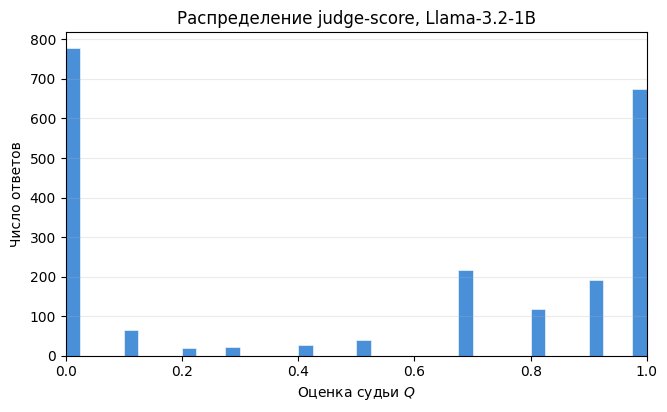

Сохранено: /Users/dmitrijsergienko/course/project-final-report/figures/judge_quality_histogram.png (n=2154, модель llama1b)


In [143]:
j_1b = MODELS.index("llama1b")
q_1b = y_quality[:, j_1b]
n_bins = 40
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(q_1b, bins=n_bins, range=(0, 1), color="#4a90d9", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Оценка судьи $Q$")
ax.set_ylabel("Число ответов")
ax.set_title("Распределение judge-score, Llama-3.2-1B")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.25, axis="y")

fig_dir = COURSE_ROOT / "project-final-report" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
out_path = fig_dir / "judge_quality_histogram.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Сохранено: {out_path} (n={len(q_1b)}, модель {MODELS[j_1b]})")

### Классификация quality (два бакета)

Метка 0: $Q \in [0, 0.5)$, метка 1: $Q \in [0.5, 1]$.

Признаки: тот же стек, что в свипе регрессии — PCA эмбеддинга + масштабированные ручные фичи (`feature_variants`), по умолчанию ключ `pca_32_plus_feat` (можно сменить `CLS_FEAT_KEY`).

Модель: CatBoostClassifier (гиперпараметры в духе `CatBoostRegressor` в свипе: глубина, итерации, `early_stopping`). На тесте — ROC-AUC по положительному классу.

Дополнительно: accuracy при пороге 0.5 на `predict_proba` и balanced accuracy (среднее recall по классам).


In [144]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

CLS_FEAT_KEY = "pca_32_plus_feat"
X_tr_cls, X_te_cls = feature_variants[CLS_FEAT_KEY]

THRESHOLD = 0.5


def _quality_bucket_labels(q_col):
    """0 — [0, 0.5), 1 — [0.5, 1]."""
    return (np.asarray(q_col, dtype=float) >= 0.5).astype(np.int32)

rows_cls = []
for j, m in enumerate(MODELS):
    y_tr = _quality_bucket_labels(y_train_q[:, j])
    y_te = _quality_bucket_labels(y_test_q[:, j])
    n0_tr, n1_tr = int((y_tr == 0).sum()), int((y_tr == 1).sum())
    n0_te, n1_te = int((y_te == 0).sum()), int((y_te == 1).sum())
    if len(np.unique(y_tr)) < 2:
        rows_cls.append(
            {
                "head": m,
                "features": CLS_FEAT_KEY,
                "auc_test": float("nan"),
                f"acc_test_p>={THRESHOLD}": float("nan"),
                "balanced_acc_test": float("nan"),
                "train_0_train_1": f"{n0_tr}/{n1_tr}",
                "test_0_test_1": f"{n0_te}/{n1_te}",
                "note": "train: один класс",
            }
        )
        continue
    clf = CatBoostClassifier(
        iterations=500,
        depth=7,
        learning_rate=0.03,
        loss_function="Logloss",
        l2_leaf_reg=2.0,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        eval_metric="AUC",
    )
    clf.fit(
        X_tr_cls,
        y_tr,
        eval_set=(X_te_cls, y_te),
        use_best_model=True,
    )
    if len(np.unique(y_te)) < 2:
        auc = float("nan")
        acc = float("nan")
        bal_acc = float("nan")
        note = "test: один класс"
    else:
        proba = clf.predict_proba(X_te_cls)[:, 1]
        auc = float(roc_auc_score(y_te, proba))
        y_hat = (proba >= THRESHOLD).astype(np.int32)
        acc = float(accuracy_score(y_te, y_hat))
        bal_acc = float(balanced_accuracy_score(y_te, y_hat))
        note = ""
    rows_cls.append(
        {
            "head": m,
            "features": CLS_FEAT_KEY,
            "auc_test": auc,
            f"acc_test_p>={THRESHOLD}": acc,
            "balanced_acc_test": bal_acc,
            "train_0_train_1": f"{n0_tr}/{n1_tr}",
            "test_0_test_1": f"{n0_te}/{n1_te}",
            "note": note,
        }
    )

df_cls = pd.DataFrame(rows_cls)
_fmt = {
    "auc_test": "{:.6f}",
    f"acc_test_p>={THRESHOLD}": "{:.6f}",
    "balanced_acc_test": "{:.6f}",
}
display(df_cls.style.format(_fmt))
print(
    f"AUC: качество ранжирования; acc @ p>={THRESHOLD}: доля верных меток; "
    "balanced_acc: средняя recall по классам (учитывает дисбаланс)."
)


,head,features,auc_test,acc_test_p>=0.5,balanced_acc_test,train_0_train_1,test_0_test_1,note
0,llama1b,pca_32_plus_feat,0.738531,0.675174,0.653373,735/988,178/253,
1,llama3b,pca_32_plus_feat,0.835100,0.786543,0.652822,474/1249,113/318,
2,qwen7b,pca_32_plus_feat,0.819176,0.830626,0.550169,319/1404,75/356,


AUC — качество ранжирования; acc @ p>=0.5 — доля верных меток; balanced_acc — средняя recall по классам (учитывает дисбаланс).


## Роутер: предсказания vs оракул

Взвешенный скоринг $w_q \tilde{Q} + w_l \tilde{L} + w_c c$ (как в отчёте: judge $Q$, нормированная задержка $\tilde{L}$, нормированный профиль памяти $c$) и сетка весов от $\beta$, причём $w_q = 1 - w_l - w_c$. Разница только во входе:

- pred: матрицы `pred_q_te`, `pred_t_te` (CatBoostRegressor).
- oracle-router: те же веса, но `argmax` по истинным `yq_te`, `yt_te` на тесте (верхняя граница для этого скоринга при идеальных метриках).

Ось $x$ — средняя фактическая latency выбранной модели, ось $y$ — среднее фактическое judge Q. Пунктир — $\mathrm{mean}_i \max_j Q_{ij}$.

Три отдельные точки — фиксированный выбор одной модели на всех примерах (без роутера).


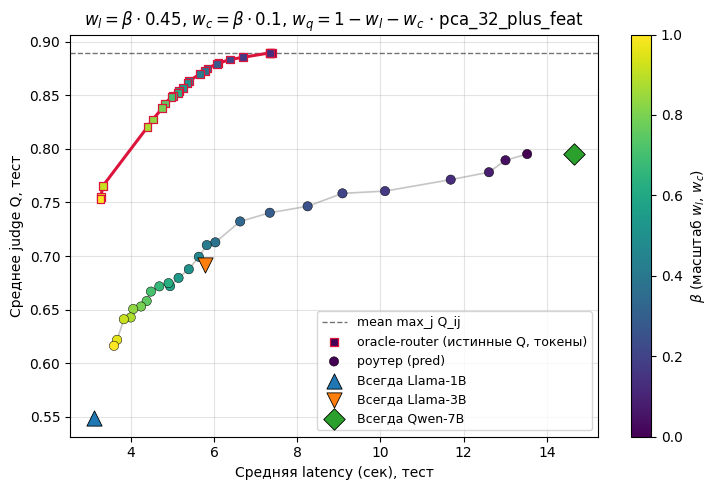

In [145]:
import sys

_repo = COURSE_ROOT
sys.path.insert(0, str(_repo))
from mlx_device_profile.constants import MODEL_MEMORY_MB as MODEL_MEMORY, MODEL_SPEEDS, MODEL_TTFT_SEC

MODEL_DISPLAY = ["Всегда Llama-1B", "Всегда Llama-3B", "Всегда Qwen-7B"]

ROUTER_WEIGHTS = {"name": "баланс Q/L + память", "w_q": 0.45, "w_l": 0.45, "w_m": 0.10}
assert abs(ROUTER_WEIGHTS["w_q"] + ROUTER_WEIGHTS["w_l"] + ROUTER_WEIGHTS["w_m"] - 1.0) < 1e-6

FEAT_KEY = "pca_32_plus_feat"

X_tr, X_te = feature_variants[FEAT_KEY]
yq_tr, yq_te = y_train_q, y_test_q
yt_tr, yt_te = y_train_t, y_test_t

_tok_hi = float(max(yt_tr.max(), yt_te.max(), 1000.0) + 1.0)


def _fit_catboost_heads(X_train, y_train, X_eval, y_eval):
    heads = []
    for j in range(len(MODELS)):
        m = create_estimator("catboost")
        m.fit(
            X_train,
            y_train[:, j],
            eval_set=(X_eval, y_eval[:, j]),
            use_best_model=True,
        )
        heads.append(m)
    return heads


q_heads = _fit_catboost_heads(X_tr, yq_tr, X_te, yq_te)
t_heads = _fit_catboost_heads(X_tr, yt_tr, X_te, yt_te)

pred_q_te = np.column_stack([h.predict(X_te) for h in q_heads])
pred_q_te = np.clip(pred_q_te, 0.0, 1.0)
pred_t_te = np.column_stack([h.predict(X_te) for h in t_heads])
pred_t_te = np.clip(pred_t_te, 50.0, _tok_hi)


def select_model_router(pred_quality, tokens_matrix, w_q, w_l, w_m):
    q = np.asarray(pred_quality, dtype=float).copy()
    latency = np.asarray(tokens_matrix, dtype=float).copy()
    for j, m in enumerate(MODELS):
        latency[:, j] = MODEL_TTFT_SEC[m] + latency[:, j] / MODEL_SPEEDS[m]
    l_min = latency.min(axis=1, keepdims=True)
    l_max = latency.max(axis=1, keepdims=True)
    l_range = np.maximum(l_max - l_min, 1e-6)
    l_norm = 1.0 - (latency - l_min) / l_range
    m_const = np.array([MODEL_MEMORY[m] for m in MODELS], dtype=float)
    m_norm = 1.0 - (m_const - m_const.min()) / (m_const.max() - m_const.min() + 1e-6)
    m_norm = np.broadcast_to(m_norm, q.shape)
    scores = w_q * q + w_l * l_norm + w_m * m_norm
    return scores.argmax(axis=1)


def metrics_after_choice(true_q, true_tokens, choices):
    row = np.arange(len(true_q))
    speeds = np.array([MODEL_SPEEDS[m] for m in MODELS], dtype=float)
    ttft = np.array([MODEL_TTFT_SEC[m] for m in MODELS], dtype=float)
    Q_mean = float(true_q[row, choices].mean())
    L_mean = float((ttft[choices] + true_tokens[row, choices] / speeds[choices]).mean())
    return Q_mean, L_mean

W_base = ROUTER_WEIGHTS
base_wl, base_wm = float(W_base["w_l"]), float(W_base["w_m"])
betas = np.linspace(0.0, 1.0, 25)
L_pred, Q_pred = [], []
L_ideal, Q_ideal = [], []
for beta in betas:
    wl = beta * base_wl
    wm = beta * base_wm
    wq = 1.0 - wl - wm
    ch_i = select_model_router(yq_te, yt_te, wq, wl, wm)
    ch_p = select_model_router(pred_q_te, pred_t_te, wq, wl, wm)
    qi, li = metrics_after_choice(yq_te, yt_te, ch_i)
    qp, lp = metrics_after_choice(yq_te, yt_te, ch_p)
    Q_ideal.append(qi)
    L_ideal.append(li)
    Q_pred.append(qp)
    L_pred.append(lp)

n_te_rows = yq_te.shape[0]
L_fix_pts, Q_fix_pts = [], []
for j in range(len(MODELS)):
    ch_fix = np.full(n_te_rows, j, dtype=int)
    qf, lf = metrics_after_choice(yq_te, yt_te, ch_fix)
    Q_fix_pts.append(qf)
    L_fix_pts.append(lf)

Q_ub = float(np.max(yq_te, axis=1).mean())

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.axhline(Q_ub, color="k", ls="--", lw=1.0, alpha=0.55, label="mean max_j Q_ij")

sc_o = ax.scatter(
    L_ideal,
    Q_ideal,
    c=betas,
    cmap="viridis",
    s=32,
    marker="s",
    edgecolors="crimson",
    linewidths=0.9,
    zorder=5,
    label="oracle-router (истинные Q, токены)",
)
ax.plot(
    L_ideal,
    Q_ideal,
    "-",
    color="crimson",
    linewidth=2.2,
    zorder=4,
)

sc = ax.scatter(
    L_pred,
    Q_pred,
    c=betas,
    cmap="viridis",
    s=45,
    edgecolors="black",
    linewidths=0.35,
    zorder=3,
    label="роутер (pred)",
)
ax.plot(L_pred, Q_pred, "-", color="gray", alpha=0.45, linewidth=1.2, zorder=2)

fix_styles = [("tab:blue", "^"), ("tab:orange", "v"), ("tab:green", "D")]
for j, (c, mk) in enumerate(fix_styles):
    ax.scatter(
        L_fix_pts[j],
        Q_fix_pts[j],
        s=120,
        marker=mk,
        c=c,
        edgecolors="black",
        linewidths=0.6,
        zorder=6,
        label=MODEL_DISPLAY[j],
    )

cb = plt.colorbar(sc, ax=ax)
cb.set_label(r"$\beta$ (масштаб $w_l$, $w_c$)")
ax.set_xlabel("Средняя latency (сек), тест")
ax.set_ylabel("Среднее judge Q, тест")
ax.set_title(
    f"$w_l=\\beta\\cdot{base_wl}$, $w_c=\\beta\\cdot{base_wm}$, "
    f"$w_q=1-w_l-w_c$ · {FEAT_KEY}"
)
handles, labels_leg = ax.get_legend_handles_labels()
uniq = dict(zip(labels_leg, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower right", fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
_out_router = _repo / "project-final-report" / "figures" / "router_oracle_vs_pred.png"
_out_router.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out_router, dpi=200, bbox_inches="tight")
plt.show()